# IIA - Trabajo Práctico 3 - Redes Neuronales

In [6]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, zero_one_loss

from copy import deepcopy

# Explorando las Redes

In [3]:
# Parámetros
"""
Comenzar y frenar el entrenamiento de una red es costoso, por lo que no
mediremos las métricas una vez por época, sino que haremos varias épocas a la
vez. Por ésto definimos sub-épocas, por ejemplo como 10, para realizar 10 épocas
a la vez y luego medir las métricas de error.
"""
sub_epocas = 25   # numero de epocas que entrena cada vez
super_epocas = 100 # numero de veces que realizaremos sub-epocas
# epocas ~= sub_epocas * super_epocas
eta = 0.01        # learning rate
alfa = 0.9        # momentum
N2 = 60            # neuronas en la capa oculta

## Definimos nuestras redes


In [ ]:
# Defino MLP para regresión
regr = MLPRegressor(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(regr)

MLPRegressor(activation='logistic', alpha=0.0, batch_size=1,
             hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
             nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


In [ ]:
# Defino MLP para clasificación
clasif = MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(clasif)

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


## Entrenamos

> **Warning**: el entrenamiento de las redes es computacionalmente pesado. Algunos de los entrenamientos que se plantean en el trabajo llevan varios minutos, dependiendo de la velocidad del procesador. El tiempo máximo en Google Colab fue de alrededor de 10 minutos. Tengan eso en cuenta para hacer el trabajo.



In [5]:
def cargar_csv(path, xcols=2, xrows=0):
    """
    Argumentos:
      path (str): ruta al archivo csv a cargar
      xcols (int): cantidad de columnas que representan las entradas,
        la columna restante representara la clase o dato de salida
    """
    if xrows == 0:
      df = pd.read_csv(path, header=None)
    else:
      df = pd.read_csv(path, header=None, nrows=xrows)
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y
    

In [5]:
def entrenar_red(red, evaluaciones,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      best_red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red
    for epoch in range(evaluaciones):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(zero_one_loss(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = zero_one_loss(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
    return best_red, error_train, error_val, error_test

In [ ]:
# Cargamos los datos...
X, y = cargar_csv('xor.csv')

# Hacemos el split de training y testing
X2, X_test, y2, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.2)  # para xor de 200 me quedan 40 de test

# y spliteamos el training en training y validacion
X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X2, y2, test_size=0.2)  # para xor de 160 me quedan 32 de val

# Corremos el entrenamiento
clasif, e_train, e_val, e_test = entrenar_red(
    clasif, super_epocas, X_train, y_train, X_val, y_val, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py

## Ploteamos Algunas Métricas

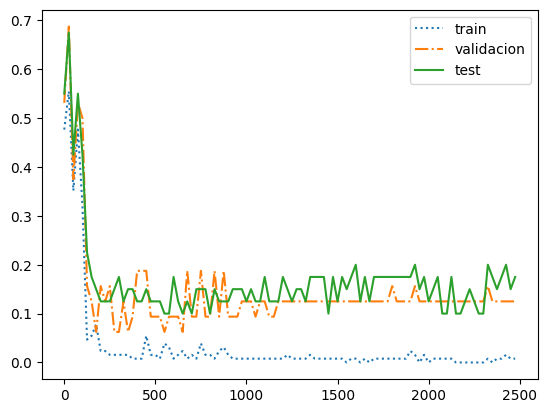

In [ ]:
rango = np.array(range(super_epocas)) * sub_epocas
plt.plot(rango, e_train, label="train", linestyle=":")
plt.plot(rango, e_val, label="validacion", linestyle="-.")
plt.plot(rango, e_test, label="test", linestyle="-")
plt.legend()
plt.show()

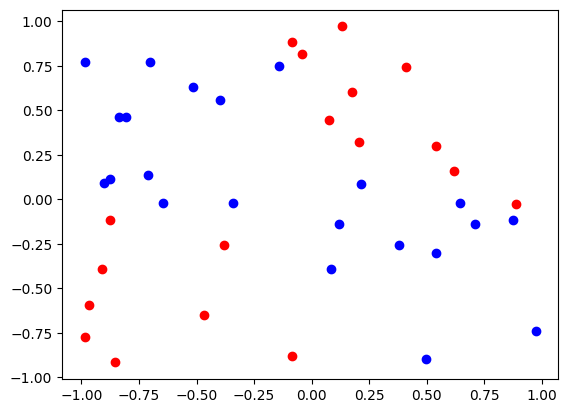

In [ ]:
y_out = clasif.predict(X_test)
X_out = X_test.copy()
X_out[2] = y_out

# diferenciar entre clase 0 y clase 1
c0 = X_out.loc[X_out[2] == 0]
c1 = X_out.loc[X_out[2] == 1]

xs0 = c0[0].values.tolist()
ys0 = c0[1].values.tolist()

xs1 = c1[0].values.tolist()
ys1 = c1[1].values.tolist()

plt.scatter(xs0, ys0, color='red')
plt.scatter(xs1, ys1, color='blue')
plt.show()

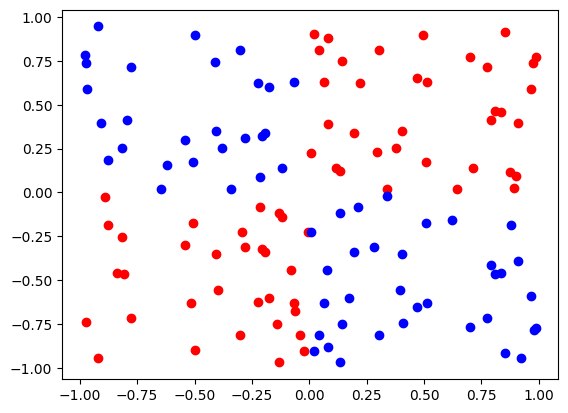

In [ ]:
# diferenciar entre clase 0 y clase 1
Xt = X_train.copy()
Xt[2] = y_train
c0 = Xt.loc[Xt[2] == 0]
c1 = Xt.loc[Xt[2] == 1]

xs0 = c0[0].values.tolist()
ys0 = c0[1].values.tolist()

xs1 = c1[0].values.tolist()
ys1 = c1[1].values.tolist()

plt.scatter(xs0, ys0, color='red')
plt.scatter(xs1, ys1, color='blue')
plt.show()

# Codigo de generacion de espirales anidadas.

In [6]:
def espirales(n: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Genera dos espirales entrelazadas con distribucion unfirome.
    """
    mid = n // 2

    def get_class_points(class_label: int, count: int) -> np.ndarray:
        points = []

        while len(points) < count:
            x = np.random.uniform(-1, 1, count)
            y = np.random.uniform(-1, 1, count)
            r = np.sqrt(x**2 + y**2)

            inside_circle = (r > 0) & (r <= 1)
            x, y, r = x[inside_circle], y[inside_circle], r[inside_circle]

            theta = np.arctan2(y, x)
            theta = np.where(theta < 0, theta + 2 * np.pi, theta)

            if class_label == 0:
                m1 = ((theta - 2*np.pi)/(4*np.pi) <= r) & (r <= (theta - np.pi)/(4*np.pi))
                m2 = (theta/(4*np.pi) <= r) & (r <= (theta + np.pi)/(4*np.pi))
                m3 = ((theta + 2*np.pi)/(4*np.pi) <= r) & (r <= (theta + 3*np.pi)/(4*np.pi))
                valid_mask = m1 | m2 | m3
            else:
                m1 = ((theta - np.pi)/(4*np.pi) <= r) & (r <= theta/(4*np.pi))
                m2 = ((theta + np.pi)/(4*np.pi) <= r) & (r <= (theta + 2*np.pi)/(4*np.pi))
                m3 = ((theta + 3*np.pi)/(4*np.pi) <= r) & (r <= (theta + 4*np.pi)/(4*np.pi))
                valid_mask = m1 | m2 | m3

            x_valid, y_valid = x[valid_mask], y[valid_mask]
            points.extend(np.column_stack((x_valid, y_valid)).tolist())

        return np.array(points[:count])

    X0 = get_class_points(class_label=0, count=mid)
    X1 = get_class_points(class_label=1, count=mid)

    X = np.vstack([X0, X1])
    y = np.concatenate((np.zeros(mid), np.ones(mid)))

    return X, y

# Ejercicio 1. Capacidad de Modelado.

In [ ]:
X, y = espirales(600)
X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X, y, test_size=0.2)

X_test, y_test = espirales(2000)

values = [2,10,20,40]
redes = {}
predictions = {}

for i in values:
  clasif = MLPClassifier(
      hidden_layer_sizes=(i,), activation='logistic', solver='sgd', alpha=0.0,
      batch_size=1, learning_rate='constant', learning_rate_init=0.1,
      momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
      max_iter=20
  )
  redes[i] = entrenar_red(clasif, 1000, X_train, y_train, X_val, y_val, X_test, y_test)
  predictions[i] = redes[i][0].predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py

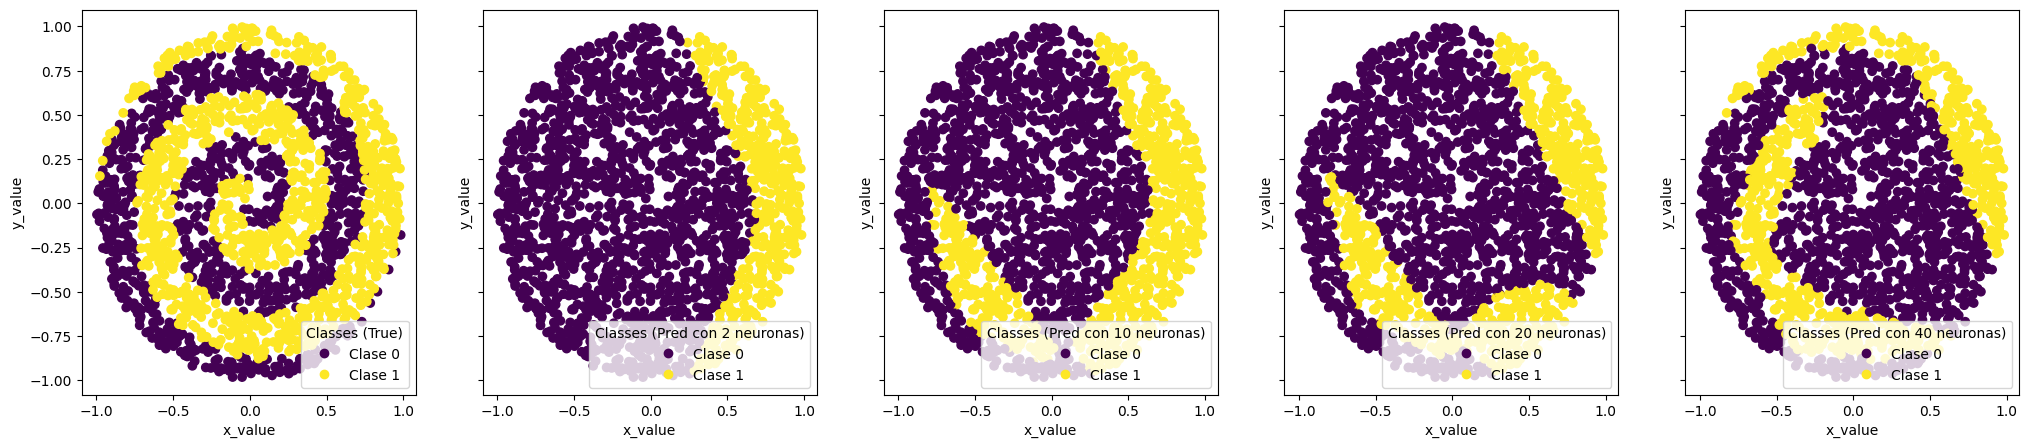

In [ ]:
_, ax = plt.subplots(1, 5, sharey=True, figsize=(25,5))

scatter = ax[0].scatter(X_test[:,0],X_test[:,1], c=y_test)
ax[0].set(xlabel="x_value", ylabel="y_value")
_ = ax[0].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (True)"
)

scatter = ax[1].scatter(X_test[:,0],X_test[:,1], c=predictions[2])
ax[1].set(xlabel="x_value", ylabel="y_value")
_ = ax[1].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (Pred con 2 neuronas)"
)

scatter = ax[2].scatter(X_test[:,0],X_test[:,1], c=predictions[10])
ax[2].set(xlabel="x_value", ylabel="y_value")
_ = ax[2].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (Pred con 10 neuronas)"
)

scatter = ax[3].scatter(X_test[:,0],X_test[:,1], c=predictions[20])
ax[3].set(xlabel="x_value", ylabel="y_value")
_ = ax[3].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (Pred con 20 neuronas)"
)

scatter = ax[4].scatter(X_test[:,0],X_test[:,1], c=predictions[40])
ax[4].set(xlabel="x_value", ylabel="y_value")
_ = ax[4].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (Pred con 40 neuronas)"
)

# Conclusiones del ejericio 1.

A primera vista, los resultados obtenidos con redes neuronales parecen ser bastante peores con arboles de desición (cosa que creiamos que no pasaria), lo que está pasando es que, al tener solo una capa oculta, la red está intentando trazar hiper-planos (rectas en 2D en este caso) para seguir la forma de las espirales, el problema con esto es que una función con tal curvatura como son las espirales son muy dificiles de aproximar con rectas, incluso cuando usamos 40 neuronas en la capa oculta, la aproximación no alcanza a dar una vuelta completa, si hubiera una segunda capa oculta, la red seria capaz de 'curvar' estos hiper-planos para darles la forma que tienen las espirales. En relación al nombre de la sección, 'Capacidad de modelado', vemos que aumentar la cantidad de neuronas en la capa oculta, mejora la capacidad de la red de modelar espirales, pero no tanto como lo harian 2 capas.

# Ejercicio 2. Mínimos Locales.

In [7]:
def entrenar_red_clasif(red, evaluaciones,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      best_red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red
    best_test = 1.0
    for epoch in range(evaluaciones):
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(zero_one_loss(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = zero_one_loss(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      y_pred_test = red.predict(X_test)
      cur_test = zero_one_loss(y_test, y_pred_test)
      error_test.append(cur_test)

      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
        best_test = cur_test
    return best_red, error_train, error_val, error_test, best_test

In [ ]:
elipse_data_X, elipse_data_y = cargar_csv("dos_elipses.data", xrows=500)
elipse_test_X, elipse_test_y = cargar_csv("dos_elipses.test", xrows=2000)

X_train,X_val,y_train , y_val = skl.model_selection.train_test_split(
    elipse_data_X, elipse_data_y, test_size=0.2)

momentum = [0,0.5,0.9]
learning = [0.1,0.01,0.001]
error_test_mean = {}

def ejecutar_entrenamiento(m, l):
    clasif = MLPClassifier(
        hidden_layer_sizes=(6,), activation='logistic', solver='sgd', alpha=0.0,
        batch_size=1, learning_rate='constant', learning_rate_init=l,
        momentum=m, nesterovs_momentum=False, tol=0.0, warm_start=True,
        max_iter=50
    )

    _, _, _, _, best_test = entrenar_red_clasif(clasif, 300, X_train, y_train, X_val, y_val, elipse_test_X, elipse_test_y)
    return (m, l, best_test)

tareas = []
for m in momentum:
    for l in learning:
        for iter in range(10):
            tareas.append((m, l))

resultados = Parallel(n_jobs=-1)(delayed(ejecutar_entrenamiento)(m, l) for m, l in tareas)

error_test_mean = {}

for m in momentum:
    for l in learning:
        current_errors = [res[2] for res in resultados if res[0] == m and res[1] == l]
        error_test_mean[(m, l)] = np.mean(current_errors)

/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stoc

In [9]:
filas_tabla = []

for m in momentum:
    for l in learning:
        filas_tabla.append({
            "Momentum": m,
            "Learning Rate": l,
            "Error de Test": round(error_test_mean[(m, l)], 4)
        })
df_resumen = pd.DataFrame(filas_tabla)

tabla_formateada = df_resumen.style.format({
    "Momentum": "{:.2}",
    "Learning Rate": "{:.2}",
    "Error de Test": "{:.2%}"
})

display(tabla_formateada)

,Momentum,Learning Rate,Error de Test
0,0.0,0.1,14.28%
1,0.0,0.01,24.35%
2,0.0,0.001,24.35%
3,0.5,0.1,11.59%
4,0.5,0.01,24.35%
5,0.5,0.001,24.35%
6,0.9,0.1,6.73%
7,0.9,0.01,8.74%
8,0.9,0.001,24.35%


# Conclusiones del ejercicio 2 (Tabla)

Analizando la tabla podemos ver algunas relaciones entre los valores.

*   Si nos fijamos en un valores de learning rate (por ej 0.1) y variamos el valor de momentum, el error promedio parece disminuir (en el ejemplo, de ~16% a ~7%)
*   Por otro lado, si nos centramos en un valor de momentum (por ej 0.5) y variamos el learning rate, obtenemos cada vez peores resultados (en el ejemplo, de ~9% a ~24%)

Con esto llegamos a la conclusion de que, en el caso de las elipses, nos interesa un valor de momentum 'grande' para no caer en los minimos locales, esto porque en el borde de las elipses la diferencia entre un punto que esta en una elipse o fuera de la misma es minima.

Ademas, observamos que valores de learning rate más altos (0.1) alcanzan los mejores resultados bajo nuestras condiciones. Esto se debe a que un valor muy bajo (0.001) produce actualizaciones de pesos demasiado pequeñas, haciendo que la convergencia sea extremadamente lenta y no logre alcanzar el mínimo global dentro de la cantidad de épocas que realizamos.

In [39]:
plot_clasif = MLPClassifier(
        hidden_layer_sizes=(6,), activation='logistic', solver='sgd', alpha=0.0,
        batch_size=1, learning_rate='constant', learning_rate_init=0.1,
        momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
        max_iter=50
        )

_, train, val, test, _ = entrenar_red_clasif(plot_clasif, 300, X_train, y_train, X_val, y_val, elipse_test_X, elipse_test_y)

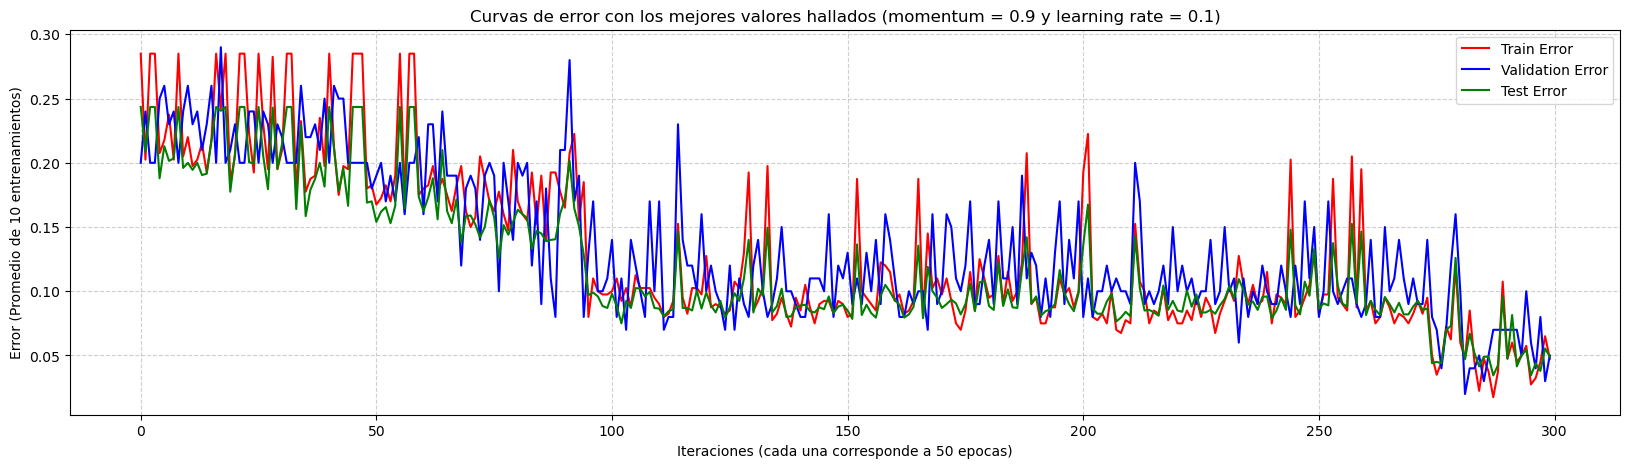

In [41]:
fig, ax1 = plt.subplots(1, 1, figsize=(20,5))

ax1.plot(range(300), train, label='Train Error', color='red')
ax1.plot(range(300), val, label='Validation Error', color='blue')
ax1.plot(range(300), test, label='Test Error', color='green')

ax1.set_title('Curvas de error con los mejores valores hallados (momentum = 0.9 y learning rate = 0.1)')
ax1.set_xlabel('Iteraciones (cada una corresponde a 50 epocas)')
ax1.set_ylabel('Error (Promedio de 10 entrenamientos)')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.6)

# Conclusiones del ejercicio 2 (Grafica)

Mostramos la grafica de los errores de train, validation y test para los mejores valores obtenidos. Se puede ver que las curvas se convergen al mismo valor y ademas no difieren mucho segun avanzan las epocas; por esto, el modelo no sufre de sobreajuste.

Por lo que los valores de momentum y learning rate hallados garantizan lelgar a un minimo absoluto en este problema particular.

# Ejercicio 3. Regularización

In [1]:
def entrenar_red_regresor(red, evaluaciones,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Funcion casi identica a la funcion entrenar_red proveida
    con la diferencia de que los errores se calculan usande mse
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = float('inf')
    best_test = float('inf')
    best_red = red
    for epoch in range(evaluaciones):
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(mean_squared_error(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = mean_squared_error(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      y_pred_test = red.predict(X_test)
      cur_test = mean_squared_error(y_test, y_pred_test)
      error_test.append(cur_test)
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
        best_test = cur_test
    return best_red, error_train, error_val, error_test, best_test

In [2]:
def cargar_csv_sep(path, xcols=2, xrows=0):
    """
    Argumentos:
      path (str): ruta al archivo csv a cargar
      xcols (int): cantidad de columnas que representan las entradas,
        la columna restante representara la clase o dato de salida
    """
    if xrows == 0:
      df = pd.read_csv(path, header=None, sep=r'\s+')
    else:
      df = pd.read_csv(path, header=None, nrows=xrows, sep=r'\s+')
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y

In [29]:
ikeda_data_X, ikeda_data_y = cargar_csv_sep("ikeda.data", xcols=5)
ikeda_test_X, ikeda_test_y = cargar_csv_sep("ikeda.test", xcols=5)

train_val = {}
train_val[0] = skl.model_selection.train_test_split(ikeda_data_X, ikeda_data_y, test_size=0.05)
train_val[1] = skl.model_selection.train_test_split(ikeda_data_X, ikeda_data_y, test_size=0.25)
train_val[2] = skl.model_selection.train_test_split(ikeda_data_X, ikeda_data_y, test_size=0.5)

def entrenar_un_modelo(i, eta, alfa, train_val, ikeda_test_X, ikeda_test_y):
    regr = MLPRegressor(
        hidden_layer_sizes=(30,), activation='logistic', solver='sgd', alpha=0.0,
        batch_size=1, learning_rate='constant', learning_rate_init=eta,
        momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
        max_iter=50
    )

    _, _, _, _, best_test = entrenar_red_regresor(
        regr, 400, train_val[i][0], train_val[i][2], 
        train_val[i][1], train_val[i][3], ikeda_test_X, ikeda_test_y
    )
    
    return i, best_test

tareas = []
for i in range(3):
    for _ in range(10):
        tareas.append((i, eta, alfa, train_val, ikeda_test_X, ikeda_test_y))

resultados_paralelos = Parallel(n_jobs=-1)(
    delayed(entrenar_un_modelo)(*args) for args in tareas
)

error_test_mean = []

for i in range(3):
    current_errors = [res[1] for res in resultados_paralelos if res[0] == i]
    error_test_mean.append(np.mean(current_errors))

/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stoc

In [30]:
filas_tabla = [
    {
    "Testsize": "95%",
    "Validation size": "5%",
    "Error de Test": round(error_test_mean[0], 4)
    },
    {
    "Testsize": "75%",
    "Validation size": "25%",
    "Error de Test": round(error_test_mean[1], 4)
    },
    {
    "Testsize": "50%",
    "Validation size": "50%",
    "Error de Test": round(error_test_mean[2], 4)
    }
]

df_resumen = pd.DataFrame(filas_tabla)
tabla_formateada = df_resumen.style.format({
    "Test size": "{:.2}",
    "validation": "{:.2}",
    "Error de Test": "{:.2%}"
})

display(tabla_formateada)

,Testsize,Validation size,Error de Test
0,95%,5%,8.45%
1,75%,25%,8.63%
2,50%,50%,13.59%


In [31]:
res = []

for i in range(3):
    regr = MLPRegressor(
        hidden_layer_sizes=(30,), activation='logistic', solver='sgd', alpha=0.0,
        batch_size=1, learning_rate='constant', learning_rate_init=eta,
        momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
        max_iter=50
    )
    _, train, val, test, _ = entrenar_red_regresor(regr, 400, train_val[i][0], train_val[i][2], train_val[i][1], train_val[i][3], ikeda_test_X, ikeda_test_y)
    res.append((train, val, test))

/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stoc

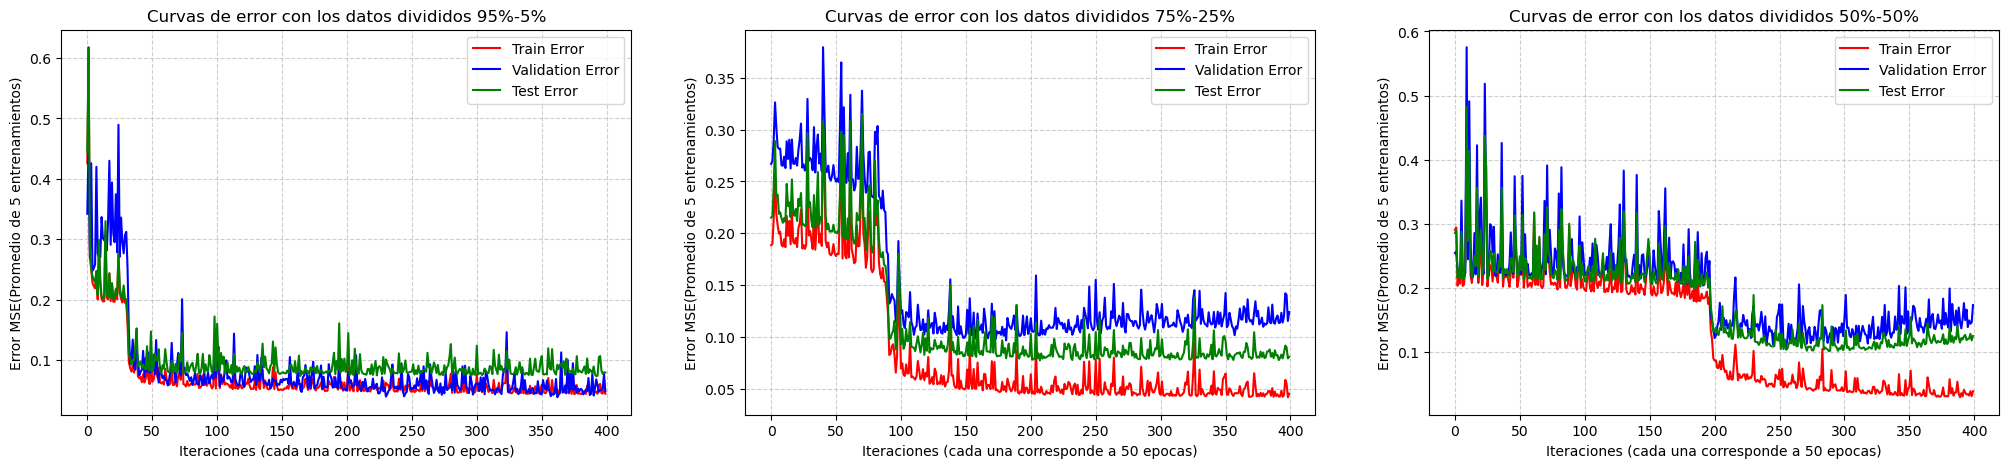

In [32]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25,5))

ax1.plot(range(400), res[0][0], label='Train Error', color='red')
ax1.plot(range(400), res[0][1], label='Validation Error', color='blue')
ax1.plot(range(400), res[0][2], label='Test Error', color='green')

ax1.set_title('Curvas de error con los datos divididos 95%-5%')
ax1.set_xlabel('Iteraciones (cada una corresponde a 50 epocas)')
ax1.set_ylabel('Error MSE(Promedio de 5 entrenamientos)')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.6)

ax2.plot(range(400), res[1][0], label='Train Error', color='red')
ax2.plot(range(400), res[1][1], label='Validation Error', color='blue')
ax2.plot(range(400), res[1][2], label='Test Error', color='green')

ax2.set_title('Curvas de error con los datos divididos 75%-25%')
ax2.set_xlabel('Iteraciones (cada una corresponde a 50 epocas)')
ax2.set_ylabel('Error MSE(Promedio de 5 entrenamientos)')
ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.6)

ax3.plot(range(400), res[2][0], label='Train Error', color='red')
ax3.plot(range(400), res[2][1], label='Validation Error', color='blue')
ax3.plot(range(400), res[2][2], label='Test Error', color='green')

ax3.set_title('Curvas de error con los datos divididos 50%-50%')
ax3.set_xlabel('Iteraciones (cada una corresponde a 50 epocas)')
ax3.set_ylabel('Error MSE(Promedio de 5 entrenamientos)')
ax3.legend()
ax3.grid(True, which="both", ls="--", alpha=0.6)

# Conclusiones del ejericio 3

La comparación de los tres graficos demuestra que el rendimiento de la red no depende únicamente de la arquitectura, sino tambien de la cantidad de datos de entrenamiento. La división 95%-5% permite una convergencia rápida y logra generalizar, mientras que, la partición 50%-50% es un mal modelo para aprender, esto porque las curvas de error de train y validaion divergen. En conclusión, para este dataset, la forma en que dividimos del conjunto de train y el conjunto de validation es imnportante para evitar el sobreajuste y asegurar que la red aprenda la estructura del problema.

# Ejercicio 4. Regularización (2).

In [ ]:
def entrenar_red_regresor_weight(red, evaluaciones, X_train, y_train, X_test, y_test):
    error_train = []
    error_test = []
    error_penalty = []
    best_test = float('inf')
    
    for epoch in range(evaluaciones):
        red.fit(X_train, y_train)
        
        y_pred_train = red.predict(X_train)
        error_train.append(mean_squared_error(y_train, y_pred_train))
        
        y_pred_test = red.predict(X_test)
        cur_test = mean_squared_error(y_test, y_pred_test)
        error_test.append(cur_test)
        
        if cur_test < best_test:
            best_test = cur_test
            
        penalty = sum(np.sum(np.abs(w)) for w in red.coefs_)
        error_penalty.append(penalty)
        
    return error_train, error_penalty, error_test, best_test

In [99]:
def entrenar_modelo_gamma(gamma, X_train, y_train, X_test, y_test):
    regr = MLPRegressor(
        hidden_layer_sizes=(6,), activation='logistic', solver='sgd', alpha=gamma,
        batch_size=1, learning_rate='constant', learning_rate_init=0.05,
        momentum=0.3, nesterovs_momentum=False, tol=0.0, warm_start=True,
        max_iter=20
    )
    
    train, test, pen, best_test = entrenar_red_regresor_weight(regr, 4000, X_train, y_train, X_test, y_test)
    
    return gamma, train, pen, test, best_test

gamma_values = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1]

ssp_data_X, ssp_data_y = cargar_csv("ssp.data", xcols=12)
ssp_test_X, ssp_test_y = cargar_csv("ssp.test", xcols=12)

results_parallel = Parallel(n_jobs=-1)(
    delayed(entrenar_modelo_gamma)(g, ssp_data_X, ssp_data_y, ssp_test_X, ssp_test_y) 
    for g in gamma_values
)

results = {}
for gamma, error_train, error_test, error_penalty, best_test in results_parallel:
    results[gamma] = [error_train, error_penalty, error_test, best_test]

/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stoc

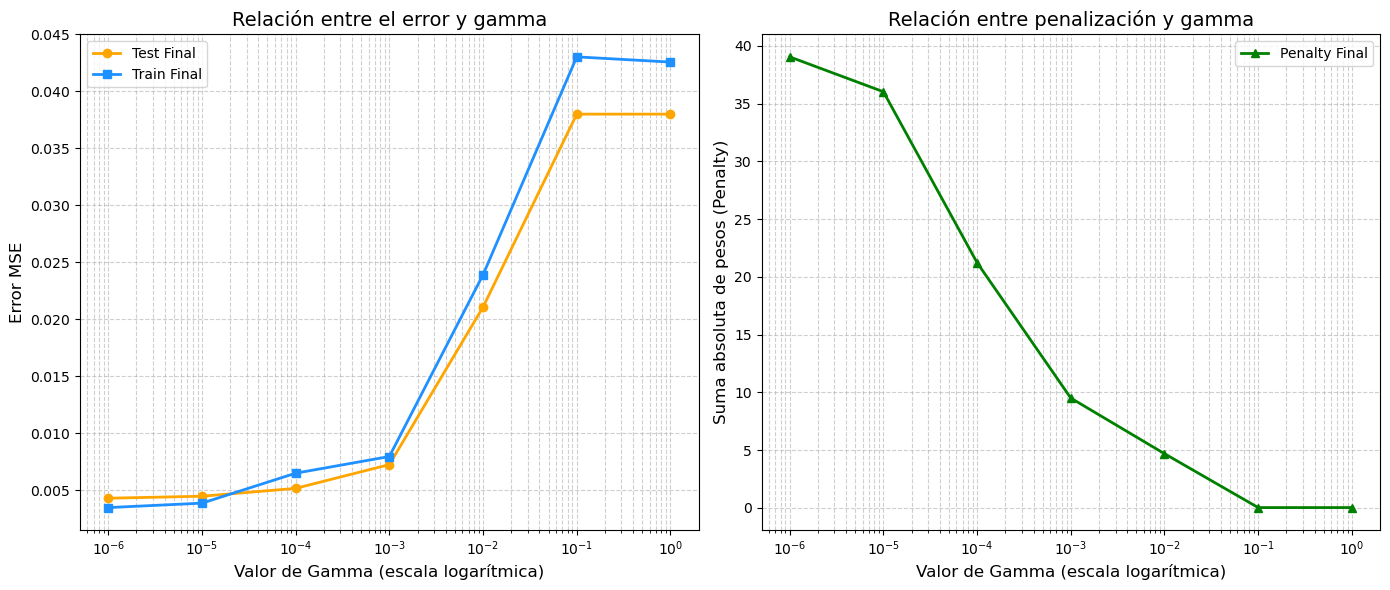

In [110]:
best_error_test = [results[g][3] for g in gamma_values]
errores_finales_train = [results[g][0][-1] for g in gamma_values]
penalty_finales = [results[g][1][-1] for g in gamma_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(gamma_values, best_error_test, marker='o', linewidth=2, color='orange', label='Test Final')
ax1.plot(gamma_values, errores_finales_train, marker='s', linewidth=2, color='dodgerblue', label='Train Final')
ax1.set_xscale('log')
ax1.set_xlabel('Valor de Gamma (escala logarítmica)', fontsize=12)
ax1.set_ylabel('Error MSE', fontsize=12)
ax1.set_title('Relación entre el error y gamma', fontsize=14)
ax1.grid(True, which="both", linestyle="--", alpha=0.6)
ax1.legend()
ax2.plot(gamma_values, penalty_finales, marker='^', linewidth=2, color='green', label='Penalty Final')
ax2.set_xscale('log')
ax2.set_xlabel('Valor de Gamma (escala logarítmica)', fontsize=12)
ax2.set_ylabel('Suma absoluta de pesos (Penalty)', fontsize=12)
ax2.set_title('Relación entre penalización y gamma', fontsize=14)
ax2.grid(True, which="both", linestyle="--", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# Conclusiones del ejericio 4 (Eleccion del gamma)

El grafico anterior muestra la relacion entre los valores de gamma y los errores de test y train, el objetivo del grafico es hallar un balance entre reducir el sobreajuste pero no tanto como para que la red no pueda aprender nada, en este caso, elegimos el valor que parece hacer lo que queremos, 10⁻³, ya que ambas curvas estan bastante juntas (no hay sobreajuste) y es exactamente antes de que los errores se disparen a partir de 10⁻²

Ademas vamos a elegir el valor, 10⁻6 para ver el sobreajuste

Tambien vemos como aumentar gamma, reduce la suma en valor absoluto de los pesos, esto es porque valores chicos de gamma hacen que estos valores 'pesen' poco al calcular el costo final (cost = error + suma de pesos), asimismo, valores muy grandes de gamma, hacen que esta suma tienda a 0.

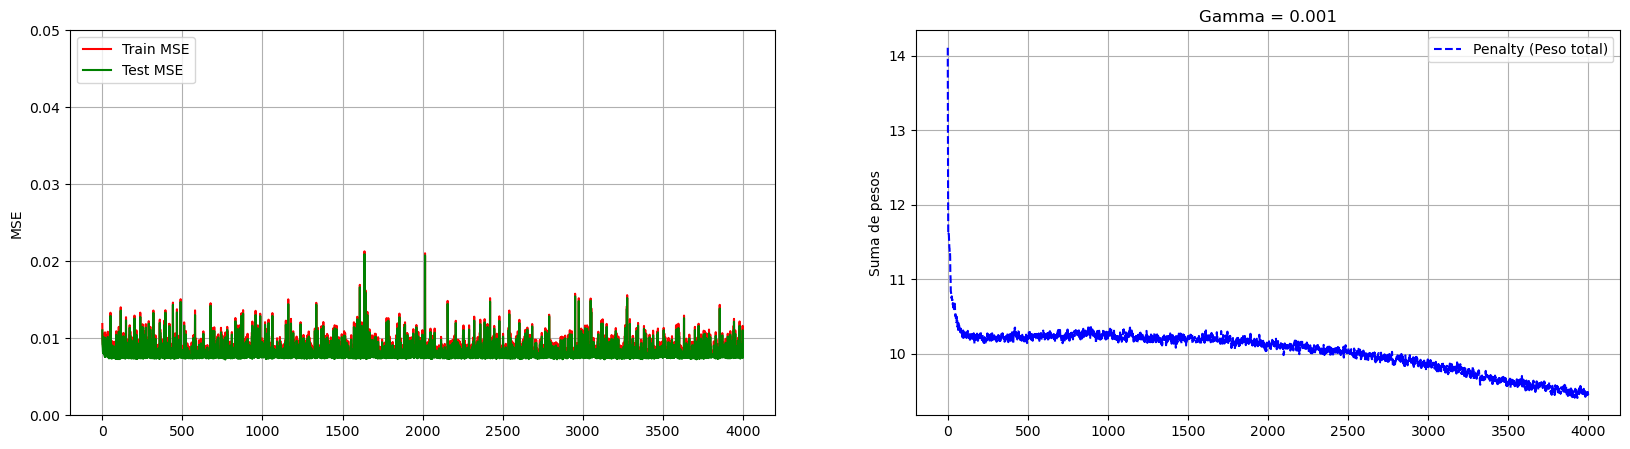

In [107]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

# Eje Y izquierdo: Errores (Train y Test)
ax1.plot(range(4000), results[0.001][0], label='Train MSE', color='red')
ax1.plot(range(4000), results[0.001][2], label='Test MSE', color='green')
ax1.set_ylabel('MSE')
ax1.set_ylim(0, 0.05)
ax1.legend(loc='upper left')
ax1.grid(True)

# Eje Y derecho: Penalización (Penalty) 
ax2.plot(range(4000), results[0.001][1], label='Penalty (Peso total)', color='blue', linestyle='--')
ax2.set_ylabel('Suma de pesos')
ax2.legend(loc='upper right')

plt.title(f'Gamma = {0.001}')
plt.grid(True)

# Conclusiones del ejericio 4 (Errores con gamma elegido)

Podemos ver que los errores se mantienen constantes a lo largo de las epocas y ademas no sobreajusta. Ademas, la suma de los pesos en valor absoluto, es cada vez menor. Esto quiere decir que encontramos el balance esperado entre no sobreajustar y tener valores de pesos chicos ya que estos son preferibles para que la red aprenda.

# Ejercicio 5. Dimensionalidad.

# (OPCIONAL) Ejercicio 6. Multiclase.

# (OPCIONAL) Ejercicio 7. Minibatch.

In [17]:
ssp_data_X, ssp_data_y = cargar_csv("ssp.data", xcols=12)
ssp_test_X, ssp_test_y = cargar_csv("ssp.test", xcols=12)
batches = [1, 16, 32]

X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(ssp_data_X, ssp_data_y, test_size=0.2)
res = {}

for i in batches:
    regr = MLPRegressor(
            hidden_layer_sizes=(6,), activation='logistic', solver='sgd', alpha=0,
            batch_size=i, learning_rate='constant', learning_rate_init=0.05,
            momentum=0.3, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=200
    )
    res[i] = entrenar_red_regresor(regr, 2000, X_train, y_train, X_val, y_val, ssp_test_X, ssp_test_y)

/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: 

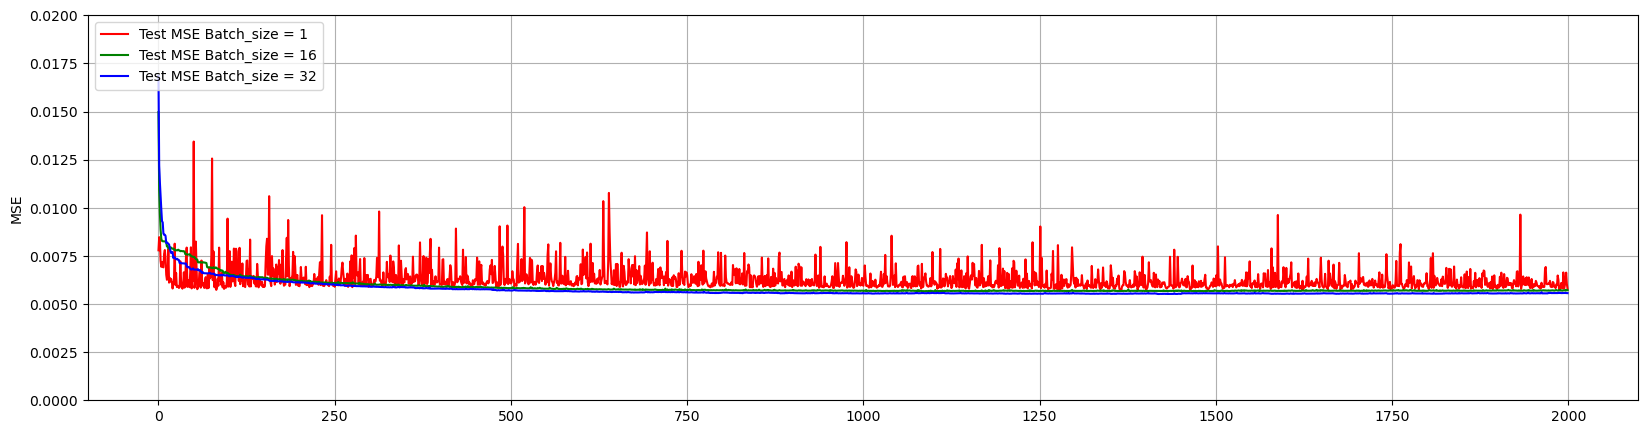

In [18]:
fig, ax1 = plt.subplots(1, 1, figsize=(20, 5))

# Eje Y izquierdo: Errores (Train y Test)
ax1.plot(range(2000), res[1][3],  label='Test MSE Batch_size = 1',  color='red')
ax1.plot(range(2000), res[16][3], label='Test MSE Batch_size = 16', color='green')
ax1.plot(range(2000), res[32][3], label='Test MSE Batch_size = 32', color='blue')
ax1.set_ylabel('MSE')
ax1.set_ylim(0, 0.02)
ax1.legend(loc='upper left')
ax1.grid(True)
plt.grid(True)